In [2]:
from seeq import spy
spy.jobs.schedule("every day at 8:05 AM")


[spy.jobs MOCK] schedule('every day at 8:05 AM') — ignorado localmente


# 06 · Modelo Estatístico de RUL — Weibull

Substitui o RandomForestRegressor por uma abordagem estatística baseada na
**distribuição de Weibull**, projetada especificamente para modelar desgaste mecânico.

| Etapa | Descrição |
|---|---|
| A | Identificar ciclos genuínos (desgaste real, não prematuros) |
| B | Ajustar Weibull nos comprimentos de ciclo |
| C | Calcular RUL condicional com intervalo P10–P50–P90 |
| D | Score de degradação por features do sinal *(próximo sprint)* |
| E | Validação temporal nos ciclos passados |

> **Por que Weibull?** É a distribuição padrão para tempo de falha de componentes mecânicos.
> Com β > 1 ela captura desgaste progressivo — quanto mais velho o maintacker, maior a taxa de falha.

In [3]:
import sys
sys.path.insert(0, '..')

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from IPython.display import display

pd.set_option('display.float_format', '{:.1f}'.format)

## Etapa A — Ciclos genuínos
Detecta resets de `target_rul` e separa trocas por desgaste real das trocas prematuras
usando um limiar configurável em `target_rul_restante`.

In [4]:
# ── Configurações ──────────────────────────────────────────────────────
LIMIAR_GENUINO_H  = 20   # target_rul_restante < N → desgaste real
ARQUIVO_TROCAS    = 'troca_modulo.csv'
COLUNA_DATA_TROCA = 'Data-base do inicio'
# ───────────────────────────────────────────────────────────────────────

df = pd.read_csv('00_hour_prev.csv')
df['ts']  = pd.to_datetime(df['Timestamp'])
df['rul'] = pd.to_numeric(df['target_rul'], errors='coerce')
df = df.sort_values('ts').reset_index(drop=True)

# Detectar resets via rul.diff() > 0
# LIMITACAO: a ultima troca nao e detectada porque target_rul vai a NaN
# (nao ha troca futura conhecida apos ela), entao diff() retorna NaN, nao > 0.
df['is_reset'] = df['rul'].diff() > 0
reset_idx = df[df['is_reset']].index

rows = []
for idx in reset_idx:
    prev = idx - 1
    if prev < 0:
        continue
    rows.append({
        'ts_ultimo'          : df.loc[prev, 'ts'],
        'ts_primeiro'        : df.loc[idx,  'ts'],
        'target_rul_restante': df.loc[prev, 'rul'],
        'novo_rul_inicial'   : df.loc[idx,  'rul'],
    })

swaps = pd.DataFrame(rows).reset_index(drop=True)

# ── Complementar com trocas confirmadas do CSV nao capturadas pelo diff ─
# Resolve o problema da ultima troca: target_rul -> NaN apos ela,
# portanto diff() nao detecta o reset. Lemos o CSV e adicionamos as
# trocas confirmadas que estao ausentes em swaps.
try:
    tc = pd.read_csv(ARQUIVO_TROCAS)
    troca_dates_csv = pd.to_datetime(tc[COLUNA_DATA_TROCA], utc=True).sort_values().tolist()

    # Alinhar fuso horario com o df
    ref_tz = df['ts'].dt.tz
    if ref_tz is not None:
        troca_dates_csv = [t.tz_convert(ref_tz) for t in troca_dates_csv]
    else:
        troca_dates_csv = [t.tz_localize(None) for t in troca_dates_csv]

    extras = []
    for troca_dt in troca_dates_csv:
        # Verificar se ja capturada (algum swap dentro de ±48h)
        if len(swaps) > 0:
            diffs_s = (swaps['ts_ultimo'] - troca_dt).abs().dt.total_seconds()
            if diffs_s.min() <= 48 * 3600:
                continue  # ja detectada pelo diff

        mask_antes  = df['ts'] < troca_dt
        mask_depois = df['ts'] >= troca_dt
        if not mask_antes.any() or not mask_depois.any():
            continue  # fora do intervalo de dados

        extras.append({
            'ts_ultimo'          : df[mask_antes]['ts'].iloc[-1],
            'ts_primeiro'        : df[mask_depois]['ts'].iloc[0],
            'target_rul_restante': df[mask_antes]['rul'].iloc[-1],
            'novo_rul_inicial'   : np.nan,
        })

    if extras:
        swaps = pd.concat([swaps, pd.DataFrame(extras)], ignore_index=True)
        swaps = swaps.sort_values('ts_ultimo').reset_index(drop=True)
        print(f'  + {len(extras)} troca(s) adicionada(s) do CSV (nao capturadas pelo diff)')

except Exception as e:
    print(f'Aviso ao ler {ARQUIVO_TROCAS}: {e}')

# Duracao de cada ciclo: do ts_primeiro do swap anterior ate o ts_ultimo deste
duracoes = [np.nan]  # primeiro ciclo tem inicio desconhecido
for i in range(1, len(swaps)):
    dur = (swaps.loc[i, 'ts_ultimo'] - swaps.loc[i-1, 'ts_primeiro']).total_seconds() / 3600
    duracoes.append(round(dur, 2))

swaps['cycle_duration_h'] = duracoes
swaps['genuino'] = swaps['target_rul_restante'] < LIMIAR_GENUINO_H

print(f'Total de resets           : {len(swaps)}')
print(f'Ciclos com duracao medida : {swaps["cycle_duration_h"].notna().sum()}')
print(f'Genuinos (heuristica)     : {swaps["genuino"].sum()}')
print(f'Prematuros / adesivo      : {(~swaps["genuino"]).sum()}')
print()
swaps[['ts_ultimo', 'target_rul_restante', 'cycle_duration_h', 'genuino']].head(15)

  + 4 troca(s) adicionada(s) do CSV (nao capturadas pelo diff)
Total de resets           : 13
Ciclos com duracao medida : 12
Genuinos (heuristica)     : 10
Prematuros / adesivo      : 3



,ts_ultimo,target_rul_restante,cycle_duration_h,genuino
0,2022-07-12 19:49:01-03:00,1.2,NaN,True
1,2022-10-20 19:03:01-03:00,1.9,2391.9,True
2,2023-02-06 11:14:01-03:00,9.8,2599.9,True
3,2023-02-22 19:05:00-03:00,2569.9,376.0,False
4,2023-06-09 16:45:59-03:00,4.2,2557.5,True
5,2023-06-18 19:18:40-03:00,1.7,208.0,True
6,2023-08-21 12:20:01-03:00,8.7,1521.3,True
7,2023-09-22 21:03:18-03:00,1823.9,760.1,False
8,2023-12-07 20:59:37-03:00,0.0,1729.5,True
9,2024-08-16 20:21:02-03:00,0.6,6063.4,True


In [5]:
# Estatísticas dos ciclos genuínos
genuinos = swaps[swaps['genuino'] & swaps['cycle_duration_h'].notna() & (swaps['cycle_duration_h'] > 0)]
cycle_lengths = genuinos['cycle_duration_h'].values

print(f'Ciclos genuínos usados no ajuste: {len(cycle_lengths)}')
print(f'Duração mínima : {cycle_lengths.min():.1f}h')
print(f'Duração mediana: {np.median(cycle_lengths):.1f}h  ({np.median(cycle_lengths)/24:.1f} dias)')
print(f'Duração máxima : {cycle_lengths.max():.1f}h')
print(f'Desvio padrão  : {cycle_lengths.std():.1f}h')

Ciclos genuínos usados no ajuste: 9
Duração mínima : 208.0h
Duração mediana: 2512.2h  (104.7 dias)
Duração máxima : 6063.4h
Desvio padrão  : 1516.0h


## Etapa B — Ajuste da distribuição de Weibull

**Interpretação de β:**
- β < 1 → mortalidade infantil (falhas precoces)
- β ≈ 1 → falhas aleatórias (distribuição exponencial)
- β > 1 → **desgaste progressivo** — esperado para componentes mecânicos

**η (escala):** 63.2% dos maintackers falham antes de atingir esta hora.

In [6]:
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    c, loc_fit, scale = stats.weibull_min.fit(cycle_lengths, floc=0)

beta = c      
eta  = scale  

# CORREÇÃO: Usando o método mean() do scipy.stats
vida_media   = stats.weibull_min.mean(c, loc=0, scale=scale)           
vida_mediana = stats.weibull_min.ppf(0.5, c, loc=0, scale=scale)
vida_p10     = stats.weibull_min.ppf(0.1, c, loc=0, scale=scale)
vida_p90     = stats.weibull_min.ppf(0.9, c, loc=0, scale=scale)


if beta < 0.9:
    tipo_desgaste = 'Mortalidade infantil (β < 1) — investigar qualidade da instalação'
elif beta < 1.1:
    tipo_desgaste = 'Falhas aleatórias (β ≈ 1) — difícil prever'
elif beta < 2.0:
    tipo_desgaste = 'Desgaste progressivo moderado'
else:
    tipo_desgaste = 'Desgaste progressivo acentuado — previsão confiável'

print('=' * 50)
print('  WEIBULL — RESULTADO DO AJUSTE')
print('=' * 50)
print(f'  β (shape) = {beta:.3f}  →  {tipo_desgaste}')
print(f'  η (scale) = {eta:.1f}h')
print()
print(f'  Vida média esperada  (MTTF): {vida_media:.1f}h  ({vida_media/24:.1f} dias)')
print(f'  Vida mediana         (P50) : {vida_mediana:.1f}h  ({vida_mediana/24:.1f} dias)')
print(f'  Vida curta           (P10) : {vida_p10:.1f}h')
print(f'  Vida longa           (P90) : {vida_p90:.1f}h')
print('=' * 50)

  WEIBULL — RESULTADO DO AJUSTE
  β (shape) = 1.671  →  Desgaste progressivo moderado
  η (scale) = 2860.2h

  Vida média esperada  (MTTF): 2555.1h  (106.5 dias)
  Vida mediana         (P50) : 2297.0h  (95.7 dias)
  Vida curta           (P10) : 744.2h
  Vida longa           (P90) : 4711.0h


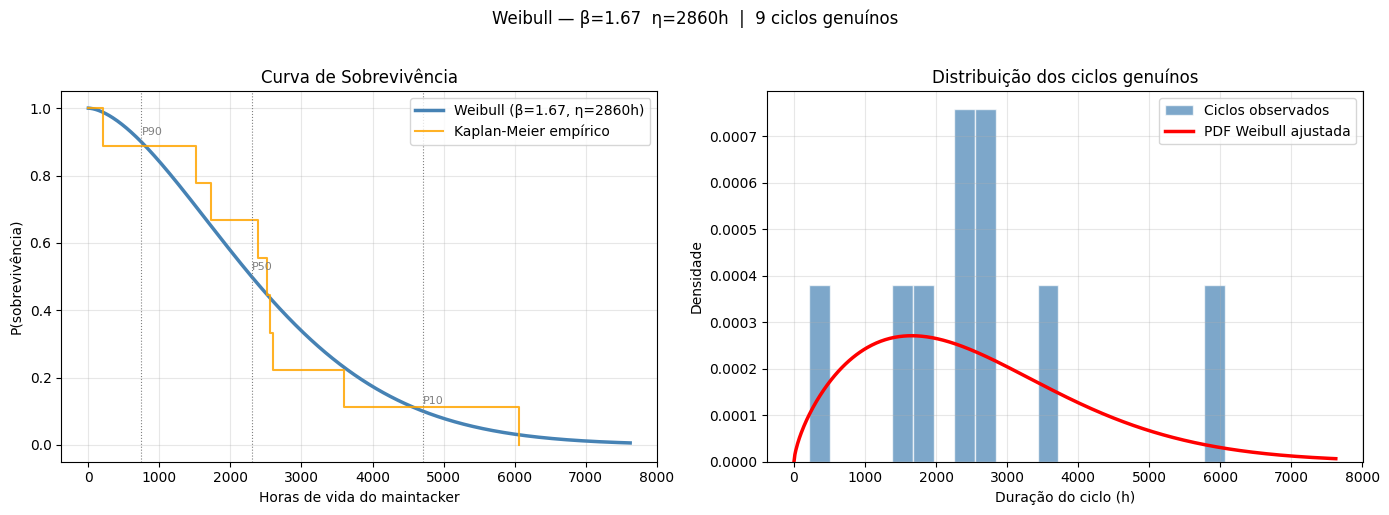

In [7]:
# Curva de sobrevivência Weibull + Kaplan-Meier empírico
t_max   = np.percentile(cycle_lengths, 99) * 1.3
t_range = np.linspace(0, t_max, 600)

S_weibull = stats.weibull_min.sf(t_range, c, loc=0, scale=scale)

# KM manual (sem censura — todos os ciclos genuínos terminaram em troca)
n = len(cycle_lengths)
sorted_dur = np.sort(cycle_lengths)
km_t = np.concatenate([[0], sorted_dur])
km_s = np.concatenate([[1.0], [(n - i) / n for i in range(1, n + 1)]])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Sobrevivência ──
axes[0].plot(t_range, S_weibull, lw=2.5, color='steelblue',
             label=f'Weibull (β={beta:.2f}, η={eta:.0f}h)')
axes[0].step(km_t, km_s, where='post', color='orange', lw=1.5, alpha=0.85,
             label='Kaplan-Meier empírico')
for p, lbl in [(0.5, 'P50'), (0.1, 'P10'), (0.9, 'P90')]:
    t_p = stats.weibull_min.ppf(1 - p, c, loc=0, scale=scale)
    axes[0].axvline(t_p, color='gray', ls=':', lw=0.8)
    axes[0].text(t_p + 2, p + 0.02, lbl, fontsize=8, color='gray')
axes[0].set_xlabel('Horas de vida do maintacker')
axes[0].set_ylabel('P(sobrevivência)')
axes[0].set_title('Curva de Sobrevivência')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Histograma + PDF ──
axes[1].hist(cycle_lengths, bins=20, color='steelblue', edgecolor='white',
             alpha=0.7, density=True, label='Ciclos observados')
axes[1].plot(t_range, stats.weibull_min.pdf(t_range, c, loc=0, scale=scale),
             lw=2.5, color='red', label='PDF Weibull ajustada')
axes[1].set_xlabel('Duração do ciclo (h)')
axes[1].set_ylabel('Densidade')
axes[1].set_title('Distribuição dos ciclos genuínos')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle(f'Weibull — β={beta:.2f}  η={eta:.0f}h  |  {len(cycle_lengths)} ciclos genuínos', y=1.02)
plt.tight_layout()
plt.savefig('weibull_survival.png', dpi=120)
plt.show()

## Etapa C — RUL condicional (P10 / P50 / P90)

Para cada ponto no tempo, calculamos o RUL restante **dado que o maintacker já sobreviveu
`horas_no_ciclo` horas**.

**Fórmula do quantil condicional:**
```
p_atual  = F(t)                           # fração de maintackers que já falharam até t
p_alvo_q = p_atual + (1 - p_atual) × q   # quantil q da vida RESTANTE
RUL_q    = F⁻¹(p_alvo_q) − t             # horas adicionais
```

In [8]:
def rul_condicional_vec(h_vec, q, c, scale):
    """Vetorizado: RUL no quantil q dado array de horas decorridas."""
    p_atual = stats.weibull_min.cdf(h_vec, c, loc=0, scale=scale)
    p_alvo  = np.minimum(p_atual + (1 - p_atual) * q, 0.9999)
    t_alvo  = stats.weibull_min.ppf(p_alvo, c, loc=0, scale=scale)
    return np.maximum(0.0, t_alvo - h_vec)


def prob_falha_janela_vec(h_vec, c, scale, janela_h=168):
    """Vetorizado: P(falha nos próximos janela_h h | sobreviveu até h)."""
    p_atual  = stats.weibull_min.cdf(h_vec, c, loc=0, scale=scale)
    p_futuro = stats.weibull_min.cdf(h_vec + janela_h, c, loc=0, scale=scale)
    denominador = np.maximum(1 - p_atual, 1e-10)
    risco = np.where(p_atual >= 0.9999, 1.0, (p_futuro - p_atual) / denominador)
    return np.clip(risco, 0, 1)


# ── Atribuir cada linha ao seu ciclo e calcular horas decorridas ──────
df['horas_no_ciclo'] = np.nan
df['ciclo_id']       = -1

# Ciclos intermediários: entre swap[i-1] e swap[i]
for i in range(1, len(swaps)):
    ts_inicio = swaps.loc[i - 1, 'ts_primeiro']
    ts_fim    = swaps.loc[i,     'ts_ultimo']
    mask = (df['ts'] >= ts_inicio) & (df['ts'] <= ts_fim)
    elapsed = (df.loc[mask, 'ts'] - ts_inicio).dt.total_seconds() / 3600
    df.loc[mask, 'ciclo_id']       = i
    df.loc[mask, 'horas_no_ciclo'] = elapsed.values

# Ciclo atual (após o último swap)
ts_inicio_atual = swaps.iloc[-1]['ts_primeiro']
mask_atual = df['ts'] >= ts_inicio_atual
elapsed_atual = (df.loc[mask_atual, 'ts'] - ts_inicio_atual).dt.total_seconds() / 3600
df.loc[mask_atual, 'ciclo_id']       = len(swaps)
df.loc[mask_atual, 'horas_no_ciclo'] = elapsed_atual.values

print(f'Linhas com ciclo atribuído: {(df["ciclo_id"] >= 0).sum()} / {len(df)}')

Linhas com ciclo atribuído: 2354 / 2359


In [9]:
# ── Calcular RUL e risco (vetorizado) ─────────────────────────────────
valid = df['horas_no_ciclo'].notna() & (df['horas_no_ciclo'] >= 0)
h = df.loc[valid, 'horas_no_ciclo'].values

df.loc[valid, 'rul_w_p10']      = rul_condicional_vec(h, 0.10, c, scale)
df.loc[valid, 'rul_w_p50']      = rul_condicional_vec(h, 0.50, c, scale)
df.loc[valid, 'rul_w_p90']      = rul_condicional_vec(h, 0.90, c, scale)
df.loc[valid, 'risco_falha_7d'] = prob_falha_janela_vec(h, c, scale, janela_h=168)

def status_operacional(risco):
    if pd.isna(risco):   return 'Desconhecido'
    if risco >= 0.70:    return '🔴 CRÍTICO'
    if risco >= 0.35:    return '🟡 ATENÇÃO'
    return '🟢 NORMAL'

df['status_weibull'] = df['risco_falha_7d'].apply(status_operacional)

print('Distribuição de status:')
print(df['status_weibull'].value_counts().to_string())
print()

# Leitura mais recente
ultimo = df[valid].iloc[-1]
print('── Leitura mais recente ──────────────────────')
print(f'  Timestamp       : {ultimo["ts"]}')
print(f'  Horas no ciclo  : {ultimo["horas_no_ciclo"]:.1f}h')
print(f'  RUL P10–P50–P90 : {ultimo["rul_w_p10"]:.0f}h – {ultimo["rul_w_p50"]:.0f}h – {ultimo["rul_w_p90"]:.0f}h')
print(f'  Risco 7 dias    : {ultimo["risco_falha_7d"]:.1%}')
print(f'  Status          : {ultimo["status_weibull"]}')

Distribuição de status:
status_weibull
🟢 NORMAL        2354
Desconhecido       5

── Leitura mais recente ──────────────────────
  Timestamp       : 2026-04-29 20:04:45-03:00
  Horas no ciclo  : 3760.5h
  RUL P10–P50–P90 : 148h – 914h – 2679h
  Risco 7 dias    : 11.3%
  Status          : 🟢 NORMAL


## Etapa E — Validação temporal
Para cada ciclo genuíno passado: quanto o Weibull P50 errou em relação ao `target_rul_restante`
medido no momento da troca?

In [10]:
val_rows = []
for i, swap_row in swaps.iterrows():
    if not swap_row['genuino'] or pd.isna(swap_row['cycle_duration_h']):
        continue
    ciclo_df = df[df['ciclo_id'] == i].sort_values('ts')
    if ciclo_df.empty or ciclo_df['rul_w_p50'].isna().all():
        continue
    last = ciclo_df.dropna(subset=['rul_w_p50']).iloc[-1]
    val_rows.append({
        'ciclo'            : i,
        'ts_fim'           : swap_row['ts_ultimo'],
        'horas_no_ciclo'   : last['horas_no_ciclo'],
        'rul_real_restante': swap_row['target_rul_restante'],
        'rul_w_p10'        : last['rul_w_p10'],
        'rul_w_p50'        : last['rul_w_p50'],
        'rul_w_p90'        : last['rul_w_p90'],
        'risco_7d'         : last['risco_falha_7d'],
        'dentro_intervalo' : last['rul_w_p10'] <= swap_row['target_rul_restante'] <= last['rul_w_p90'],
    })

val_df = pd.DataFrame(val_rows)

if len(val_df):
    mae  = (val_df['rul_w_p50'] - val_df['rul_real_restante']).abs().mean()
    cob  = val_df['dentro_intervalo'].mean()
    high_risk_at_end = (val_df['risco_7d'] >= 0.35).mean()

    print(f'Ciclos genuínos validados       : {len(val_df)}')
    print(f'MAE Weibull P50                 : {mae:.1f}h')
    print(f'Cobertura intervalo P10–P90     : {cob:.1%}  (ideal ≥ 80%)')
    print(f'% ciclos com risco ≥ 35% ao fim : {high_risk_at_end:.1%}  (ideal alto — modelo detectou o risco)')
    display(val_df)

Ciclos genuínos validados       : 9
MAE Weibull P50                 : 1220.0h
Cobertura intervalo P10–P90     : 0.0%  (ideal ≥ 80%)
% ciclos com risco ≥ 35% ao fim : 0.0%  (ideal alto — modelo detectou o risco)


,ciclo,ts_fim,horas_no_ciclo,rul_real_restante,rul_w_p10,rul_w_p50,rul_w_p90,risco_7d,dentro_intervalo
0,1,2022-10-20 19:03:01-03:00,2392.0,1.9,197.9,1157.9,3175.6,0.1,False
1,2,2023-02-06 11:14:01-03:00,2599.9,9.8,187.7,1111.7,3088.1,0.1,False
2,4,2023-06-09 16:45:59-03:00,2557.5,4.2,189.7,1120.8,3105.6,0.1,False
3,5,2023-06-18 19:18:40-03:00,208.0,1.7,587.8,2113.7,4518.3,0.0,False
4,6,2023-08-21 12:20:01-03:00,1521.3,8.7,260.7,1409.0,3603.7,0.1,False
5,8,2023-12-07 20:59:37-03:00,1729.6,0.0,241.6,1338.7,3491.2,0.1,False
6,9,2024-08-16 20:21:02-03:00,6063.4,0.6,108.2,690.2,2135.5,0.2,False
7,11,2025-08-10 19:35:06-03:00,3599.5,1.4,152.4,936.8,2729.0,0.1,False
8,12,2025-11-23 20:07:39-03:00,2512.2,0.9,191.8,1130.7,3124.4,0.1,False


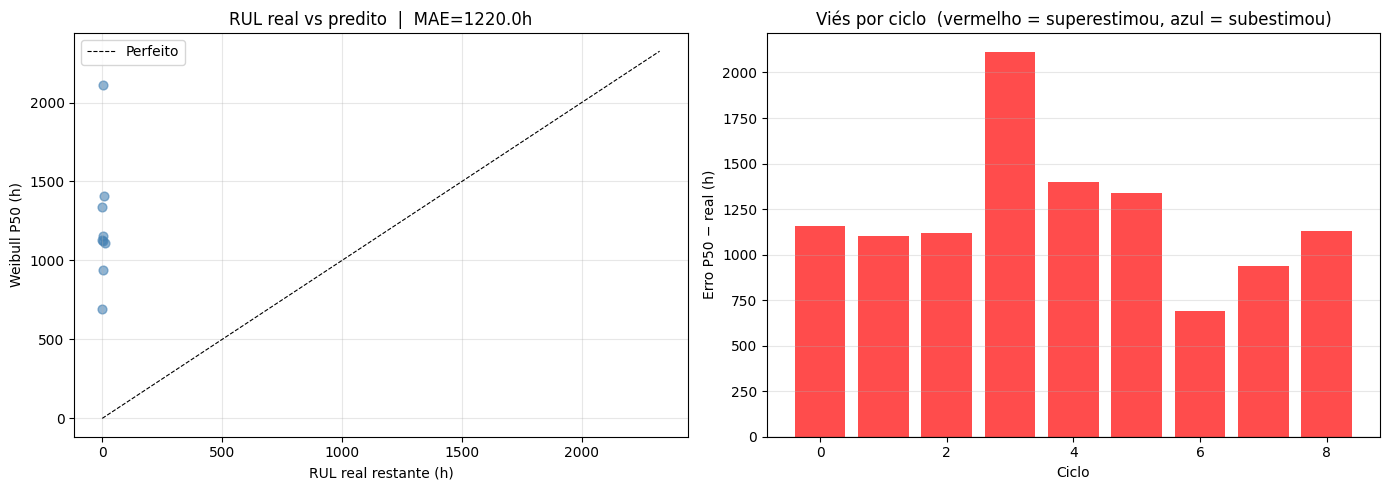

In [11]:
# Scatter: RUL real vs Weibull P50 por ciclo
if len(val_df):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Scatter ──
    axes[0].scatter(val_df['rul_real_restante'], val_df['rul_w_p50'],
                    alpha=0.6, s=40, color='steelblue')
    lim = max(val_df[['rul_real_restante', 'rul_w_p50']].max()) * 1.1
    axes[0].plot([0, lim], [0, lim], 'k--', lw=0.8, label='Perfeito')
    axes[0].set_xlabel('RUL real restante (h)')
    axes[0].set_ylabel('Weibull P50 (h)')
    axes[0].set_title(f'RUL real vs predito  |  MAE={mae:.1f}h')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # ── Erro por ciclo ──
    erro = val_df['rul_w_p50'] - val_df['rul_real_restante']
    cores = ['red' if e > 0 else 'steelblue' for e in erro]
    axes[1].bar(range(len(erro)), erro, color=cores, alpha=0.7)
    axes[1].axhline(0, color='black', lw=0.8)
    axes[1].set_xlabel('Ciclo')
    axes[1].set_ylabel('Erro P50 − real (h)')
    axes[1].set_title('Viés por ciclo  (vermelho = superestimou, azul = subestimou)')
    axes[1].grid(alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig('weibull_validation.png', dpi=120)
    plt.show()

## Visualização — série temporal com RUL Weibull

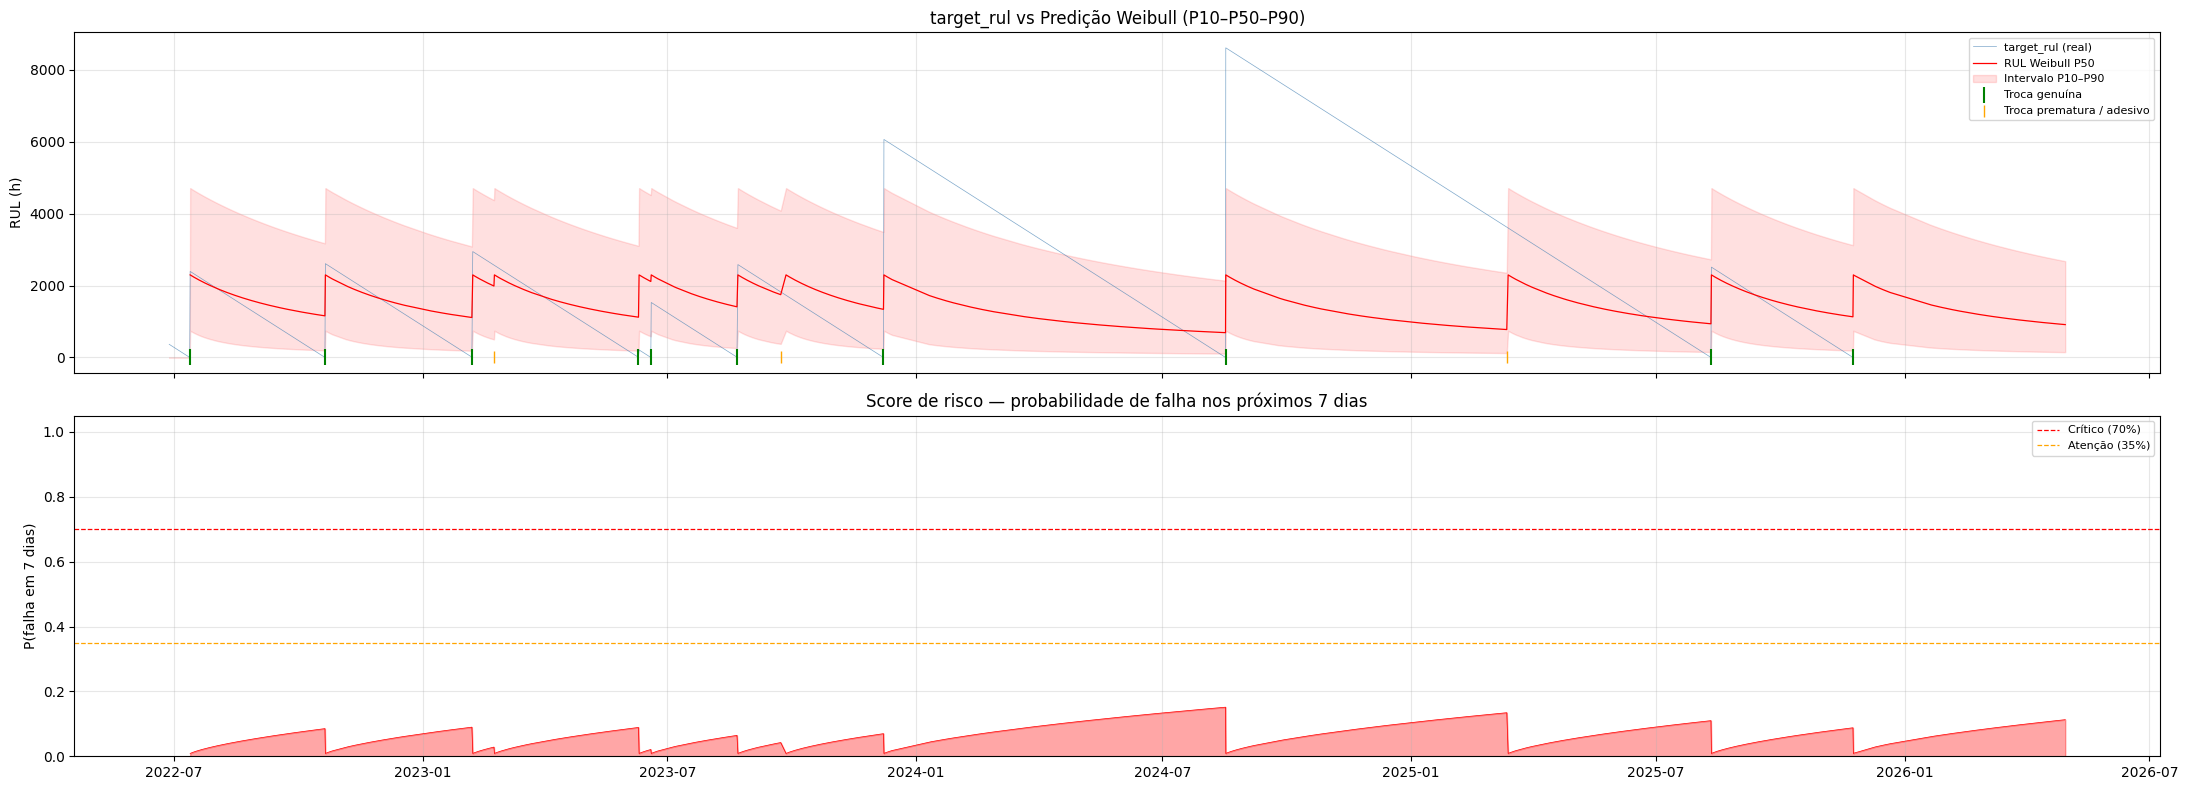

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(22, 8), sharex=True)

# ── target_rul vs Weibull ──
axes[0].plot(df['ts'], df['rul'], lw=0.5, color='steelblue', alpha=0.7, label='target_rul (real)')
axes[0].plot(df['ts'], df['rul_w_p50'], lw=0.9, color='red', label='RUL Weibull P50')
axes[0].fill_between(df['ts'],
                     df['rul_w_p10'].fillna(0),
                     df['rul_w_p90'].fillna(0),
                     alpha=0.12, color='red', label='Intervalo P10–P90')

genuinos_ts = swaps[swaps['genuino']]['ts_ultimo']
axes[0].scatter(genuinos_ts, [0] * len(genuinos_ts), color='green',
                marker='|', s=120, linewidths=1.5, zorder=5, label='Troca genuína')
prematuros_ts = swaps[~swaps['genuino']]['ts_ultimo']
axes[0].scatter(prematuros_ts, [0] * len(prematuros_ts), color='orange',
                marker='|', s=80, linewidths=1, zorder=4, label='Troca prematura / adesivo')

axes[0].set_ylabel('RUL (h)')
axes[0].set_title('target_rul vs Predição Weibull (P10–P50–P90)')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# ── Score de risco ──
risco = df['risco_falha_7d'].fillna(np.nan)
axes[1].fill_between(df['ts'], risco, 0, alpha=0.35, color='red')
axes[1].plot(df['ts'], risco, lw=0.5, color='red')
axes[1].axhline(0.70, color='red',    ls='--', lw=0.9, label='Crítico (70%)')
axes[1].axhline(0.35, color='orange', ls='--', lw=0.9, label='Atenção (35%)')
axes[1].set_ylabel('P(falha em 7 dias)')
axes[1].set_ylim(0, 1.05)
axes[1].set_title('Score de risco — probabilidade de falha nos próximos 7 dias')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('weibull_rul_series.png', dpi=120)
plt.show()

## Etapa D — Score de degradação por features do sinal
> **Próximo sprint.** Requer mais labels de trocas genuínas para treinamento confiável.

Features planejadas:
- `pct_abaixo_800N_7d` — % de leituras < 800N nos últimos 7 dias
- `pct_abaixo_700N_7d` — % < 700N
- `pior_leitura_7d` — mínimo da janela
- `cv_delta_ab_7d` — coeficiente de variação do Delta_AB (instabilidade)
- `slope_7d`, `slope_14d` — tendência de queda
- `recuperacao_subita` — indicador de salto positivo seguido de queda (adesivo?)
- `horas_no_ciclo` — tempo desde a última troca

Modelo proposto: **Logistic Regression calibrada** (Platt scaling) para `P(troca genuína em N dias)`.
Validação por **temporal split** — nunca usar dados futuros no treino.

In [13]:
# ── Placeholder — Etapa D ─────────────────────────────────────────────
# Calcular features de sinal para uso futuro

COL_A   = 'Forca_A'
COL_B   = 'Forca_B'
THRESH1 = 800
THRESH2 = 700

if COL_A in df.columns and COL_B in df.columns:
    df['media_sinal'] = (df[COL_A] + df[COL_B]) / 2

    for win in ['7D', '14D']:
        tag = win.replace('D', 'd')
        rolled = df.set_index('ts')['media_sinal'].rolling(win, min_periods=1)
        df[f'pct_abaixo_{THRESH1}N_{tag}'] = (
            df.set_index('ts')[COL_A].rolling(win, min_periods=1)
            .apply(lambda x: (x < THRESH1).mean(), raw=True).values
        )
        df[f'pior_leitura_{tag}']  = rolled.min().values
        df[f'cv_delta_ab_{tag}']   = (
            df.set_index('ts')['Delta_AB'].rolling(win, min_periods=2)
            .apply(lambda x: x.std() / x.mean() if x.mean() > 0 else 0, raw=True).values
        )

    feature_cols_d = [
        f'pct_abaixo_{THRESH1}N_7d', f'pct_abaixo_{THRESH1}N_14d',
        'pior_leitura_7d', 'pior_leitura_14d',
        'cv_delta_ab_7d',  'cv_delta_ab_14d',
        'slope_Media_14d', 'horas_no_ciclo',
    ]
    features_disponíveis = [c for c in feature_cols_d if c in df.columns]
    print('Features calculadas para Etapa D:')
    print(df[features_disponíveis].tail(5).to_string())
else:
    print(f'Colunas {COL_A} / {COL_B} não encontradas. Ajuste conforme seu config.')

Features calculadas para Etapa D:
      pct_abaixo_800N_7d  pct_abaixo_800N_14d  pior_leitura_7d  pior_leitura_14d  cv_delta_ab_7d  cv_delta_ab_14d  slope_Media_14d  horas_no_ciclo
2354                 0.2                  0.1            706.5             706.5             0.9              0.8            -17.4          3728.7
2355                 0.2                  0.1            706.5             706.5             0.9              0.8            -13.8          3736.5
2356                 0.1                  0.1            773.0             706.5             0.9              0.8            -13.9          3745.1
2357                 0.1                  0.1            773.0             706.5             0.9              0.8            -11.4          3752.4
2358                 0.1                  0.1            773.0             706.5             0.8              0.8            -13.6          3760.5


## Exportar

In [14]:
cols_export = [
    'Timestamp', 'Forca_A', 'Forca_B', 'Media', 'Delta_AB',
    'target_rul', 'pred_rul',
    'horas_no_ciclo', 'ciclo_id',
    'rul_w_p10', 'rul_w_p50', 'rul_w_p90',
    'risco_falha_7d', 'status_weibull',
]
cols_export = [c for c in cols_export if c in df.columns]

df[cols_export].to_csv('06_weibull.csv', index=False)
print(f'Exportado: hour_prev_weibull.csv  ({len(df)} linhas, {len(cols_export)} colunas)')

# Parâmetros do modelo para uso em produção
import json
modelo_params = {
    'weibull_beta'           : round(beta, 6),
    'weibull_eta'            : round(eta, 6),
    'limiar_genuino_h'       : LIMIAR_GENUINO_H,
    'n_ciclos_genuinos'      : len(cycle_lengths),
    'vida_mediana_h'         : round(float(vida_mediana), 2),
    'vida_p10_h'             : round(float(vida_p10), 2),
    'vida_p90_h'             : round(float(vida_p90), 2),
    'limiar_critico_risco'   : 0.70,
    'limiar_atencao_risco'   : 0.35,
}
with open('06_weibull_params.json', 'w') as f:
    json.dump(modelo_params, f, indent=2)
print('Exportado: weibull_params.json')

Exportado: hour_prev_weibull.csv  (2359 linhas, 13 colunas)
Exportado: weibull_params.json
